# DATASET OVERIEW 

https://physionet.org/content/eeg-power-anesthesia/1.0.0/

This database contains electroencephalography (EEG) multitaper spectra and associated conscious/unconscious labels for:
- 10 healthy volunteers undergoing stereotyped anesthetic administration and direct monitoring of subject responsiveness
- 44 patients receiving anesthesia care in an operating room (OR) context
    - Cases recorded in an OR context are further divided into those administered propofol alone under a total intravenous anesthesia (TIVA) approach, and those who received either sevoflurane alone or sevoflurane following a propofol induction

## Data description

Data containing .csv files are saved according to the following naming convention:  {CASEID}_{DATATYPE}.csv. Every case has a spectrogram calculated from N consecutive epochs and power estimates for 100 frequency bins ranging from 0-50 Hz. 

CASEIDs are unique identifiers for each volunteer or OR case. The DATATYPEs for each case were:
- Sdb: Spectrogram (dB): spectrogram calculated via multitaper for 2s epochs with no overlap between epochs.
- f: Frequencies (Hz): frequency bins from spectral estimation. For all cases f ranges from 0-50 in steps of 0.5Hz
- l: Consciousness label for each window, 0 for unconscious, 1 for conscious, NaN for OR induction during which level of unconsciousness could not be assessed
- EEGquality: boolean list for whether the EEG was recorded correctly for each spectrogram window. These files only exist for the OR cohort because the volunteer cohort had no issue with EEG dropout. Dropout was inferred by checking for total power at less than -30,000 dB summed across bins for a single 2s epoch.
- t: Time in seconds since the beginning of the EEG recording. This array is the time axis for Sdb, l, and EEGquality arrays.


## Coding

### Volunteers

In [1]:
import pandas as pd
import numpy as np

dir_volunteer = "multitaper-spectra-recorded-during-gabaergic-anesthetic-unconsciousness-1.0.0/Volunteer"

volunteer_ids = ["02","03","04","05","07","08","09","10","13","15"]

# f_02 = pd.read_csv(f"{dir_volunteer}/02_f.csv", header=None).to_numpy()
# l_02 = pd.read_csv(f"{dir_volunteer}/02_l.csv", header=None).to_numpy()
# sdb_02 = pd.read_csv(f"{dir_volunteer}/02_Sdb.csv", header=None).to_numpy()
# t_02 = pd.read_csv(f"{dir_volunteer}/02_t.csv", header=None).to_numpy()

volunteers = []

for id in volunteer_ids:
    print(id)
    _f = pd.read_csv(f"{dir_volunteer}/{id}_f.csv", header=None).to_numpy()
    _l = pd.read_csv(f"{dir_volunteer}/{id}_l.csv", header=None).to_numpy()
    _sdb = pd.read_csv(f"{dir_volunteer}/{id}_sdb.csv", header=None).to_numpy()
    _t = pd.read_csv(f"{dir_volunteer}/{id}_t.csv", header=None).to_numpy()

    volunteers.append([_f, _l, _sdb, _t])


02
03
04
05
07
08
09
10
13
15


array([[10.39842456, 18.33630218, 40.41993534, ..., 28.05003017,
        24.29661729,  1.29900387],
       [12.87680784, 21.60307607, 43.46851123, ..., 30.98834165,
        25.91895331,  4.29792359],
       [10.97885602, 21.83667131, 40.19401259, ..., 27.52500293,
        24.90515096,  1.86861969],
       ...,
       [-5.19913039, -1.72053838, -3.55776132, ...,  0.39369393,
         1.44270793, -0.91266492],
       [-4.6435577 , -1.87829055, -2.8862896 , ...,  2.17430878,
         1.88334417, -1.34669532],
       [-5.14284477, -2.06037887, -2.7855491 , ...,  2.05069921,
         2.2883318 , -0.70153574]], shape=(100, 5190))

C:\Users\mikol\AppData\Local\Temp\ipykernel_8148\953411759.py:12: UserWarning: Only one segment is calculated since parameter NFFT (=256) >= signal length (=100).
  ax[y,x].specgram(v[2], cmap="rainbow")


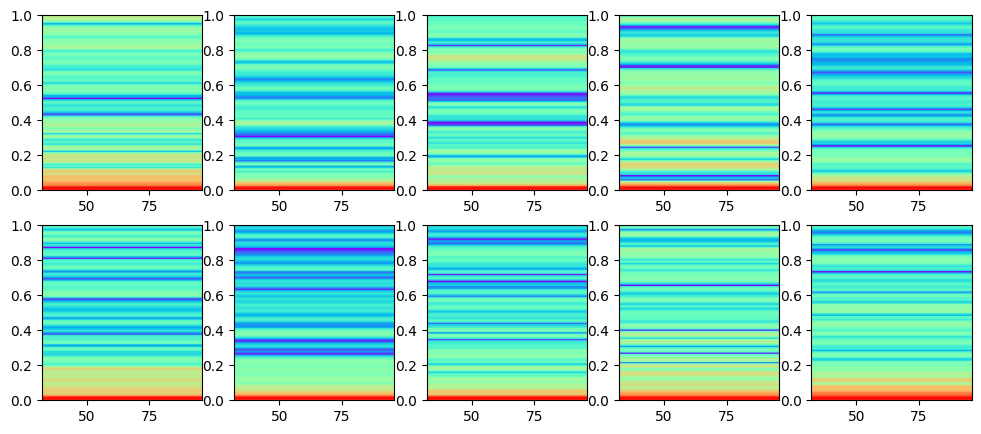

In [ ]:
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(2,5, figsize=(12,5))
x = y = 0
for v in volunteers:
    ax[y,x].specgram(v[2], cmap="rainbow")
    x+=1
    if x > 4:
        x = 0
        y += 1


In [4]:
volunteers[0][2]

array([[10.39842456, 18.33630218, 40.41993534, ..., 28.05003017,
        24.29661729,  1.29900387],
       [12.87680784, 21.60307607, 43.46851123, ..., 30.98834165,
        25.91895331,  4.29792359],
       [10.97885602, 21.83667131, 40.19401259, ..., 27.52500293,
        24.90515096,  1.86861969],
       ...,
       [-5.19913039, -1.72053838, -3.55776132, ...,  0.39369393,
         1.44270793, -0.91266492],
       [-4.6435577 , -1.87829055, -2.8862896 , ...,  2.17430878,
         1.88334417, -1.34669532],
       [-5.14284477, -2.06037887, -2.7855491 , ...,  2.05069921,
         2.2883318 , -0.70153574]], shape=(100, 5190))

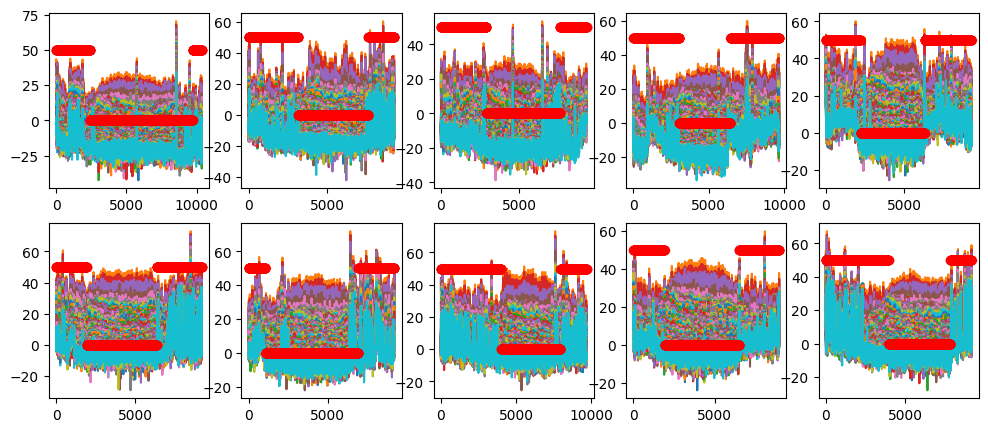

In [32]:
# for i in range(0, len(sdb_02)):
#     plt.plot(t_02, sdb_02[i])

# plt.plot(t_02, l_02*50, "o", color="r")
# idk how to add frequency to this
fig, ax = plt.subplots(2,5, figsize=(12,5))
x = y = 0
for v in volunteers:
    for i in range(0, len(v[2])):
        ax[y,x].plot(v[3], v[2][i])

    ax[y,x].plot(v[3], v[1]*50, "o", color="r", alpha=0.25)
    x+=1
    if x > 4:
        x = 0
        y += 1

### Operating Room patients

In [33]:
dir_or = "multitaper-spectra-recorded-during-gabaergic-anesthetic-unconsciousness-1.0.0/OR"


### Matlab dataset